В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [162]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, auc, accuracy_score
import joblib

In [163]:
train_raw_df = pd.read_csv('train.csv')

train_raw_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15807989.0,Ch'iu,585.0,France,Male,33.0,3.0,0.00,1.0,1.0,0.0,54191.38,0.0
14996,14996,15731781.0,Ch'ang,678.0,France,Male,34.0,6.0,0.00,2.0,1.0,1.0,53437.10,0.0
14997,14997,15667093.0,Goliwe,678.0,France,Female,54.0,4.0,0.00,1.0,1.0,0.0,147720.29,1.0
14998,14998,15732644.0,Fanucci,705.0,Spain,Female,40.0,7.0,0.00,2.0,1.0,0.0,149550.95,0.0


In [164]:
train_raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [165]:
# delete CustormerId column (see task description: https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-4/overview)
train_raw_df = train_raw_df.drop('CustomerId', axis=1)
train_raw_df

,id,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,Ch'iu,585.0,France,Male,33.0,3.0,0.00,1.0,1.0,0.0,54191.38,0.0
14996,14996,Ch'ang,678.0,France,Male,34.0,6.0,0.00,2.0,1.0,1.0,53437.10,0.0
14997,14997,Goliwe,678.0,France,Female,54.0,4.0,0.00,1.0,1.0,0.0,147720.29,1.0
14998,14998,Fanucci,705.0,Spain,Female,40.0,7.0,0.00,2.0,1.0,0.0,149550.95,0.0


In [166]:
# check percentage of each value of target in the whole available data
np.round(train_raw_df.Exited.value_counts()/len(train_raw_df.Exited), 2)

,count
Exited,
0.0,0.8
1.0,0.2


In [167]:
# split to train and validation, stratify by target class label
train_df, validation_df = train_test_split(train_raw_df, test_size=0.25, random_state=42, stratify=train_raw_df.Exited)

In [168]:
# check percentage of each value of target in train dataset
np.round(train_df.Exited.value_counts()/len(train_df.Exited), 2)

,count
Exited,
0.0,0.8
1.0,0.2


In [169]:
# check percentage of each value of target in validation dataset
np.round(validation_df.Exited.value_counts()/len(validation_df.Exited), 2)

,count
Exited,
0.0,0.8
1.0,0.2


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [170]:
# define input columns (names) and target column
input_cols = list(train_df.columns)[2:-1] # columns 'id', 'Surname' and 'Exited' are excluded
target_col = list(train_df.columns)[-1:] # column 'Exited'

print(f'Input col. names: {input_cols}')
print(f'Target col. name: {target_col}')

Input col. names: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Target col. name: ['Exited']


In [171]:
# create (copy) input and target subsets for train and validation
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()
val_inputs = validation_df[input_cols].copy()
val_targets = validation_df[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [172]:
# select numeric and categorical columns (names)
numeric_cols = train_inputs.select_dtypes('number').columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

print(f'Numeric col. names: {numeric_cols}')
print(f'Categorical col. name: {categorical_cols}')

Numeric col. names: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Categorical col. name: ['Geography', 'Gender']


4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка має бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

**Підготовка числових даних:**
- перевірка і обробка пропущених і некоректних значень
- масштабування

Два стобпця з оригінальних даних - `id` та `Surname` - не беремо до уваги. Їх було виключено з списку `input_columns` на попередньому етапі у завданні 3.

In [173]:
# check missing values/NA in each numeric column of train_inputs
train_inputs[numeric_cols].isnull().sum()

,0
CreditScore,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [174]:
# check missing values/NA in each numeric column of val_inputs
val_inputs[numeric_cols].isnull().sum()

,0
CreditScore,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


У числових стовпцях наборів даних `train_inputs` i `val_inputs` немає пропущених даних - імпутація у цьому випадку не потрібна.

In [175]:
# quick check if target values contain any missing data
print(train_targets.isna().sum()), print(val_targets.isna().sum())

Exited    0
dtype: int64
Exited    0
dtype: int64


(None, None)

In [176]:
# check data statistics for numeric columns in train_inputs
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00
mean,658.99,37.69,5.02,42952.89,1.59,0.79,0.49,117904.96
std,72.12,8.14,2.78,59923.39,0.53,0.41,0.50,45553.03
min,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58
25%,603.00,32.00,3.00,0.00,1.00,1.00,0.00,83155.87
50%,661.00,37.00,5.00,0.00,2.00,1.00,0.00,123587.94
75%,709.00,42.00,7.00,109863.19,2.00,1.00,1.00,156774.94
max,850.00,72.00,10.00,209767.31,4.00,1.00,1.00,199992.48


У сеті `train_inputs` дані виглядають правдоподібно. Найменше значення в `EstimatedSalary` (11.58) виглядає занизьким, тож відсортуємо колонку і подивимось на інші значення на початку.

In [177]:
train_inputs.EstimatedSalary.sort_values().head(20)

,EstimatedSalary
12856,11.58
7232,11.58
6462,447.73
3236,447.73
9266,479.54
10643,487.30
13783,548.52
3475,548.52
7633,582.59
2850,582.59


Тут видно, що в значеннях `EstimatedSalary` є дублікати, що скоріше дивно для заробітних плат. Проте ми маємо справу саме з estimated salary (орієнтовна заробітна плата), тому такі однакові значення у даних можливо пояснюються саме конкретним методом, яким проводилась оцінка. Але перевіримо чи є у початковому датасеті дублікати рядочків по відношенню до числових колоночок.

In [178]:
train_raw_df[numeric_cols].duplicated().sum()

np.int64(0)

Дублікатів немає. Далі придивимось до декількох клієнтів з однаковими зарплатами.

In [179]:
train_raw_df[train_raw_df['EstimatedSalary'] == 11.58]

,id,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7232,7232,Milanesi,718.0,Germany,Female,35.0,8.0,123953.31,1.0,1.0,0.0,11.58,1.0
12856,12856,Okeke,661.0,France,Male,36.0,2.0,122924.75,1.0,1.0,0.0,11.58,0.0


In [180]:
train_raw_df[train_raw_df['EstimatedSalary'] == 645.61]

,id,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1293,1293,Okwuadigbo,733.0,Spain,Male,29.0,2.0,0.00,2.0,1.0,0.0,645.61,0.0
1949,1949,Chukwudi,632.0,France,Female,32.0,0.0,61671.19,1.0,0.0,0.0,645.61,0.0
3367,3367,Yermolayev,789.0,France,Male,37.0,8.0,170840.08,1.0,1.0,0.0,645.61,0.0
3642,3642,Ch'in,678.0,France,Female,35.0,2.0,0.00,2.0,1.0,1.0,645.61,0.0
4977,4977,Mazzanti,850.0,Germany,Male,41.0,7.0,115462.02,2.0,0.0,0.0,645.61,0.0
8179,8179,Ch'in,634.0,France,Female,49.0,3.0,76515.71,1.0,0.0,0.0,645.61,1.0
10706,10706,Genovese,733.0,France,Male,31.0,6.0,0.00,1.0,1.0,1.0,645.61,1.0
11285,11285,Hsia,627.0,France,Male,32.0,9.0,0.00,2.0,1.0,0.0,645.61,0.0
11707,11707,Nwabugwu,641.0,France,Male,35.0,10.0,0.00,2.0,1.0,0.0,645.61,0.0
13202,13202,Genovese,753.0,Germany,Male,49.0,1.0,107949.31,1.0,1.0,1.0,645.61,0.0


In [181]:
train_raw_df[train_raw_df['EstimatedSalary'] == 199805.63]

,id,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
2161,2161,P'an,754.0,Spain,Male,40.0,6.0,0.0,1.0,1.0,0.0,199805.63,1.0
14863,14863,Blesing,742.0,France,Female,34.0,6.0,0.0,2.0,1.0,1.0,199805.63,0.0


На прикладах даних клієнтів не спостерігається якихось узагальнюючих висновків. Тому робимо висновок, що скоріше за все, однакові значення - це вплив метода оцінки заробітньої плати, який використовували. Пізніше при масштабуванні можна буде застосувати min-max нормалізацію, бо вона не залежить від значень середнього і стандартного відхилення, на які може впливати кількість однакових значень у даних. Також можна буде спробувати RobustScaler та порівняти роботу моделі на даних коли використовували MinMaxScaler та RobustScaler.

In [182]:
# check data statistics for numeric columns in val_inputs
val_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,3750.00,3750.00,3750.00,3750.00,3750.00,3750.00,3750.00,3750.00
mean,658.81,37.89,5.03,42060.50,1.59,0.78,0.49,117423.80
std,72.67,8.44,2.76,59138.07,0.53,0.41,0.50,46278.69
min,434.00,19.00,0.00,0.00,1.00,0.00,0.00,479.54
25%,602.00,32.00,3.00,0.00,1.00,1.00,0.00,82709.80
50%,662.00,37.00,5.00,0.00,2.00,1.00,0.00,123317.58
75%,708.00,42.00,7.00,108521.93,2.00,1.00,1.00,157546.56
max,850.00,74.00,10.00,185966.64,4.00,1.00,1.00,199953.33


In [183]:
# check if there are duplicates in EstimatedSalary in validation subset
val_inputs.EstimatedSalary.sort_values().head(10)

,EstimatedSalary
2258,479.54
10556,523.00
7644,582.59
13566,582.59
11171,582.59
14628,582.59
11285,645.61
3642,645.61
11707,645.61
4977,645.61


 Числові дані в наборі  `val_inputs` виглядають правдоподібно. У `EstimatedSalary` також присутні дублікати, як і у попередньому випадку.

 Перевірка бінарних та дискретних числових даних:

In [184]:
display(train_inputs.Tenure.value_counts()), display(val_inputs.Tenure.value_counts())

,count
Tenure,
2.0,1297
5.0,1211
3.0,1191
7.0,1180
8.0,1174
9.0,1167
4.0,1162
1.0,1097
6.0,1097


,count
Tenure,
2.0,429
5.0,417
7.0,415
8.0,394
6.0,389
4.0,378
9.0,376
3.0,370
1.0,365


(None, None)

In [185]:
display(train_inputs.NumOfProducts.value_counts()), display(val_inputs.NumOfProducts.value_counts())

,count
NumOfProducts,
2.0,6236
1.0,4825
3.0,169
4.0,20


,count
NumOfProducts,
2.0,2094
1.0,1593
3.0,53
4.0,10


(None, None)

In [186]:
display(train_inputs.HasCrCard.value_counts()), display(train_inputs.IsActiveMember.value_counts())

,count
HasCrCard,
1.0,8910
0.0,2340


,count
IsActiveMember,
0.0,5725
1.0,5525


(None, None)

Бінарні і дискретні дані виглядають правдоподібно.

Min-max нормалізація числових колонок
(виконується для урівняння впливу різних ознак у моделі і для поліпшення сходження методів оптимізації, що використовуються пізніше):

In [187]:
# setup min-max scaler for numeric columns
minmax_scaler = MinMaxScaler()
minmax_scaler.fit(train_inputs[numeric_cols])

MinMaxScaler()

In [188]:
# scale data in train and validation subsets
train_inputs[numeric_cols] = minmax_scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = minmax_scaler.transform(val_inputs[numeric_cols])

**Підготовка категоріальних даних:**
- обробка пропущених та некоректних значень
- кодування категоріальних характеристик (encoding)



In [189]:
# catergorcial column names
categorical_cols

['Geography', 'Gender']

In [190]:
# values in Geography col
train_inputs.Geography.value_counts()

,count
Geography,
France,6753
Spain,2486
Germany,2011


In [191]:
# values in Gender col
train_inputs.Gender.value_counts()

,count
Gender,
Male,6449
Female,4801


In [192]:
# check missing values/NA in each categorical column of train_inputs
train_inputs[categorical_cols].isna().sum()

,0
Geography,0
Gender,0


In [193]:
# check missing values/NA in each categorical column of val_inputs
val_inputs[categorical_cols].isna().sum()

,0
Geography,0
Gender,0


У категоріальних колонках наших даних немає пропущених або некоректних значень. Це означає, що імпутація не потрібна.

Перетворюємо категоріальні колонки в числові, щоб наша модель могла їх використовувати у навчанні. У обох колонках невелике число бінарних значень: 3 (Geography) і 2 (Gender). Використовуємо one-hot encoding: цей метод простий, зручний для використання, а також у нашому випадку не призведе до утворення надмірної кількості нових колонок.

In [194]:
# setup one-hot encoder
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
onehot_encoder.fit(train_inputs[categorical_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [195]:
# set encoded column names
encoded_cols = list(onehot_encoder.get_feature_names_out(categorical_cols))
encoded_cols

['Geography_France',
 'Geography_Germany',
 'Geography_Spain',
 'Gender_Female',
 'Gender_Male']

In [196]:
# encode values in train and validation sets
train_inputs[encoded_cols] = onehot_encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = onehot_encoder.transform(val_inputs[categorical_cols])

Перевіримо як виглядають сети `train_inputs` та `val_inputs` після всіх обробок даних:

In [197]:
display(train_inputs.head())

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
8263,0.632458,France,Male,0.259259,0.5,0.622726,0.000000,1.0,1.0,0.433916,1.0,0.0,0.0,0.0,1.0
14199,0.479714,Germany,Female,0.259259,0.4,0.571232,0.000000,1.0,0.0,0.888712,0.0,1.0,0.0,1.0,0.0
1856,0.591885,France,Female,0.074074,0.4,0.000000,0.333333,1.0,1.0,0.813017,1.0,0.0,0.0,1.0,0.0
3013,0.653938,France,Male,0.555556,0.3,0.000000,0.333333,1.0,0.0,0.599071,1.0,0.0,0.0,0.0,1.0
8266,0.632458,France,Female,0.314815,0.7,0.000000,0.333333,1.0,0.0,0.502109,1.0,0.0,0.0,1.0,0.0


In [198]:
display(val_inputs.head())

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
1855,0.267303,France,Male,0.203704,0.9,0.570579,0.0,0.0,0.0,0.279047,1.0,0.0,0.0,0.0,1.0
1273,0.398568,Germany,Male,0.425926,0.3,0.590481,0.0,1.0,0.0,0.884371,0.0,1.0,0.0,0.0,1.0
5414,0.453461,France,Male,0.240741,0.7,0.000000,0.0,1.0,1.0,0.751226,1.0,0.0,0.0,0.0,1.0
10923,0.396181,France,Male,0.703704,0.3,0.000000,1.0,1.0,0.0,0.514675,1.0,0.0,0.0,0.0,1.0
5835,0.758950,Spain,Female,0.444444,0.5,0.000000,0.0,1.0,1.0,0.909003,0.0,0.0,1.0,1.0,0.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [199]:
#!pip install pyarrow --quiet

In [200]:
# saving DataFrames
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')

# saving Series (convert to DataFrame before)
pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')

In [201]:
!ls

sample_data	       test.csv   train_inputs.parquet	 val_inputs.parquet
sample_submission.csv  train.csv  train_targets.parquet  val_targets.parquet


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [202]:
# sets for train and validation containing only numeric data
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]

In [203]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
8263,0.632458,0.259259,0.5,0.622726,0.000000,1.0,1.0,0.433916,1.0,0.0,0.0,0.0,1.0
14199,0.479714,0.259259,0.4,0.571232,0.000000,1.0,0.0,0.888712,0.0,1.0,0.0,1.0,0.0
1856,0.591885,0.074074,0.4,0.000000,0.333333,1.0,1.0,0.813017,1.0,0.0,0.0,1.0,0.0
3013,0.653938,0.555556,0.3,0.000000,0.333333,1.0,0.0,0.599071,1.0,0.0,0.0,0.0,1.0
8266,0.632458,0.314815,0.7,0.000000,0.333333,1.0,0.0,0.502109,1.0,0.0,0.0,1.0,0.0


In [204]:
X_val.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
1855,0.267303,0.203704,0.9,0.570579,0.0,0.0,0.0,0.279047,1.0,0.0,0.0,0.0,1.0
1273,0.398568,0.425926,0.3,0.590481,0.0,1.0,0.0,0.884371,0.0,1.0,0.0,0.0,1.0
5414,0.453461,0.240741,0.7,0.000000,0.0,1.0,1.0,0.751226,1.0,0.0,0.0,0.0,1.0
10923,0.396181,0.703704,0.3,0.000000,1.0,1.0,0.0,0.514675,1.0,0.0,0.0,0.0,1.0
5835,0.758950,0.444444,0.5,0.000000,0.0,1.0,1.0,0.909003,0.0,0.0,1.0,1.0,0.0


In [205]:
# create and setup model
logreg_model = LogisticRegression()

In [206]:
logreg_model.fit(X_train, train_targets)

LogisticRegression()

In [207]:
# make predictions for train data
train_predicted = logreg_model.predict(X_train)
train_probabilities = logreg_model.predict_proba(X_train)

In [208]:
# make predictions for train and validation data
val_predicted = logreg_model.predict(X_val)
val_probabilities = logreg_model.predict_proba(X_val)

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [209]:
# confusion matrix for train dataset
confusion_matrix(train_targets, train_predicted)

array([[8601,  360],
       [1051, 1238]])

In [210]:
# confusion matrix for validation dataset
confusion_matrix(val_targets, val_predicted)

array([[2847,  140],
       [ 344,  419]])

In [211]:
def compute_auroc_and_build_roc(targets, probabilities, name=''):
  # Predict probabilities
  #y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve (Receiver Operating Characteristic curve)
  fpr, tpr, thresholds = roc_curve(targets, probabilities)
    # Compute AUROC (ara under the ROC curve)
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.5f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.5f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training dataset: 0.88263


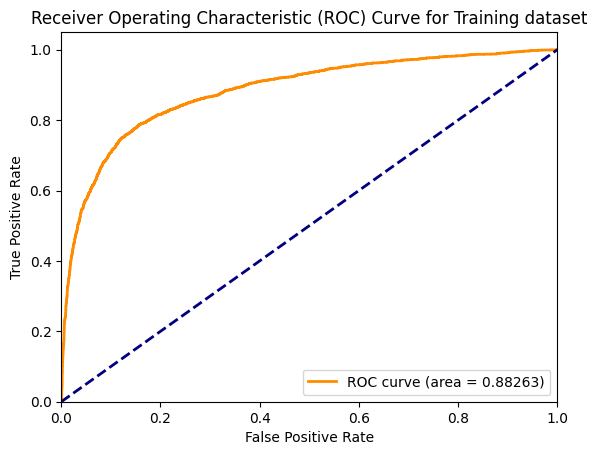

In [212]:
# calculate AUROC and build ROC-curve for train data
compute_auroc_and_build_roc(train_targets, train_probabilities[:,1], 'Training dataset')

AUROC for Validation dataset: 0.87991


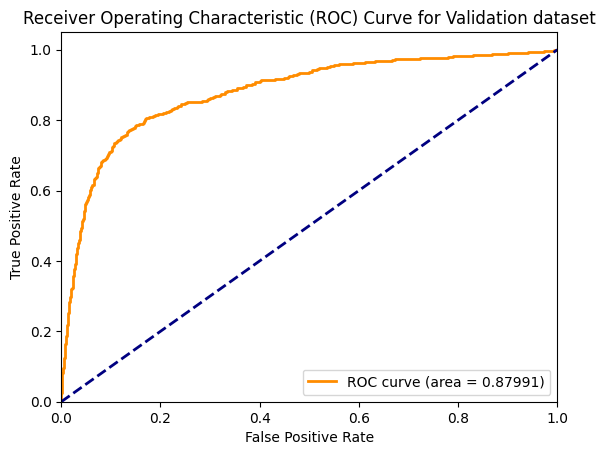

In [213]:
# calculate AUROC and build ROC-curve for validation data
compute_auroc_and_build_roc(val_targets, val_probabilities[:,1], 'Validation dataset')

In [214]:
# F1-score for train data
f1_score(train_targets, train_predicted)

0.6369951119114998

In [215]:
# F1-score for validation data
f1_score(val_targets, val_predicted)

0.6338880484114977

**Висновок**

Модель загалом є задовільною. AUROC моделі для тренувальних і валідаційних даних: 0.8826 та 0.8799 відповідно - ці два значення мають невелику різницю, що означає, що є позитивною ознакою побудованої моделі. Аналогічна ситуація і зі значеннями F1-score на тренувальному і валідаційному наборах: 0.6370 та 0.6339 відповідно.

Загалом така найпростіша модель показує непоганий результат, але її можна спробувати поліпшити, щоб досягти більш точного передбачення.



8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [216]:
# majority model: returns the element with the most frequency
def majority_model(input, targets):
  result = 0
  dict = targets.value_counts()
  val = dict[0:len(dict)].max()
  for key, value in dict.items():
    if value == val:
      result = key[0]
  return np.full(len(targets), result)

In [217]:
# majority model: prediction for target data
train_predicted_maj = majority_model(X_train, train_targets)

In [218]:
# majority model: prediction for validation data
val_predicted_maj = majority_model(X_val, val_targets)

In [219]:
# Accuracy for log. regression prediction on train data
accuracy_score(train_targets, train_predicted)

0.8745777777777778

In [220]:
# Accuracy for log. regression prediction on validation data
accuracy_score(val_targets, val_predicted)

0.8709333333333333

In [221]:
# Accuracy for maj. model prediction on train data
accuracy_score(train_targets, train_predicted_maj)

0.7965333333333333

In [222]:
# Accuracy for maj. model prediction on validation data
accuracy_score(val_targets, val_predicted_maj)

0.7965333333333333

**Висновок**

Мажоритарна модель досягає точності 79,65% на навчальному та валідаційному наборах - стільки у нас процентуально у train та validation наборах найчастішого класу (при розділенні на тренувальний та валідаційний набори ми використовували метод stratified, тому у нас однаковий процент міток одного класу у обох цих наборах даних). Наша модель логістичної регресії краща за мажоритарну згідо показника accuracy, але вона також спроможна краще узагальнювати дані, ніж мажоритарна модель, яка є у якійсь мірі детерміністичною.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [223]:
# create dictionary with data to store
bank_customer_behavior = {
    'model': logreg_model,
    'scaler': minmax_scaler,
    'encoder': onehot_encoder,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
}

In [224]:
# store data
joblib.dump(bank_customer_behavior, 'log_reg.joblib')

['log_reg.joblib']

In [225]:
# load data
model_2 = joblib.load('log_reg.joblib')

In [226]:
model_2['categorical_cols']

['Geography', 'Gender']

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [227]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    prob = logreg_model.predict_proba(X_input)[:,1]
    return prob

In [228]:
# make prediction for the first 5 observations in train_raw_df (data before split to train and validation)
predict_raw_df(minmax_scaler, onehot_encoder, numeric_cols, categorical_cols, train_raw_df[:5])

array([0.00643172, 0.0368165 , 0.37107721, 0.37857354, 0.97588748])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [229]:
# load data
test_raw_df = pd.read_csv('test.csv')
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [230]:
# make prediction for test data
test_predicted_probs = predict_raw_df(minmax_scaler, onehot_encoder, numeric_cols, categorical_cols, test_raw_df)

In [231]:
test_predicted_probs[0:10]

array([0.07453302, 0.03444022, 0.15156741, 0.19670564, 0.05492193,
       0.16639489, 0.14350503, 0.12113329, 0.04050954, 0.06636429])

In [232]:
# add new column (Exited) with predicted probabilities of observation to refer to class 1
test_raw_df['Exited'] = np.round(test_predicted_probs,2)
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Exited
0,15000,15594796.0,Chu,0.365155,Germany,Male,0.222222,0.2,0.696265,0.000000,1.0,1.0,0.789477,0.0,1.0,0.0,0.0,1.0,0.07
1,15001,15642821.0,Mazzi,0.286396,France,Male,0.388889,0.5,0.000000,0.333333,1.0,1.0,0.337131,1.0,0.0,0.0,0.0,1.0,0.03
2,15002,15716284.0,Onyekachi,0.656325,France,Male,0.462963,0.8,0.000000,0.333333,1.0,0.0,0.783859,1.0,0.0,0.0,0.0,1.0,0.15
3,15003,15785078.0,Martin,0.682578,Spain,Male,0.500000,0.3,0.000000,0.000000,1.0,1.0,0.834571,0.0,0.0,1.0,0.0,1.0,0.20
4,15004,15662955.0,Kenechukwu,0.384248,Spain,Male,0.462963,0.8,0.000000,0.333333,1.0,1.0,0.718421,0.0,0.0,1.0,0.0,1.0,0.05


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [233]:
# read from file
sample_submission_data = pd.read_csv('sample_submission.csv')
sample_submission_data.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [234]:
# add data into submission file (according to id)
sample_submission_data['Exited'] = sample_submission_data['id'].map(
    test_raw_df.set_index('id')['Exited']
)

In [235]:
sample_submission_data.head()

,id,Exited
0,15000,0.07
1,15001,0.03
2,15002,0.15
3,15003,0.20
4,15004,0.05


In [236]:
sample_submission_data.to_csv('sample_submission.csv', index=False)